In [70]:
import contextily as cx
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import yaml
from matplotlib_scalebar.scalebar import ScaleBar
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

with open("../data/crs.yaml", "r") as fp:
    crs = yaml.safe_load(fp)
with open("../plotting_config.yaml", "r") as fp:
    config = yaml.safe_load(fp)

In [3]:
def load_isochrones(city: str, version: str) -> gpd.GeoDataFrame:
    isochrones = gpd.read_file(
        f"../output/{city}/{version}/isochrones.geojson",
        engine="pyogrio",
    )
    isochrones["stop_id"] = isochrones["stop_id"].apply(str)
    return isochrones

In [ ]:
stops = pd.read_csv("../data/stops/budapest/20250428/clustered_stops.csv")
stops = gpd.GeoDataFrame(stops, geometry=gpd.points_from_xy(stops["stop_lon"], stops["stop_lat"]), crs=4326)
stops.to_crs(23700, inplace=True)

,stop_id,stop_name,stop_lat,stop_lon,clust,geometry
0,007877,Bíróság,47.519481,18.978040,2120,POINT (644773.033 241731.058)
1,007879,"Római úti lakótelep, Varsa utca",47.570863,19.058543,1752,POINT (650835.138 247441.201)
2,007881,Váradi utca,47.543645,19.030374,1947,POINT (648715.018 244415.344)


In [4]:
isochrones = load_isochrones("budapest", "20250428")

In [17]:
STOP = '069089'
a15 = isochrones[(isochrones["stop_id"] == STOP) & (isochrones["costing"] == "walk") & (isochrones["range"] == 15)].copy()
a5 = isochrones[(isochrones["stop_id"] == STOP) & (isochrones["costing"] == "walk") & (isochrones["range"] == 5)].copy()

In [28]:
c15 = "#D17BA5"
c5 = "#6E5480"

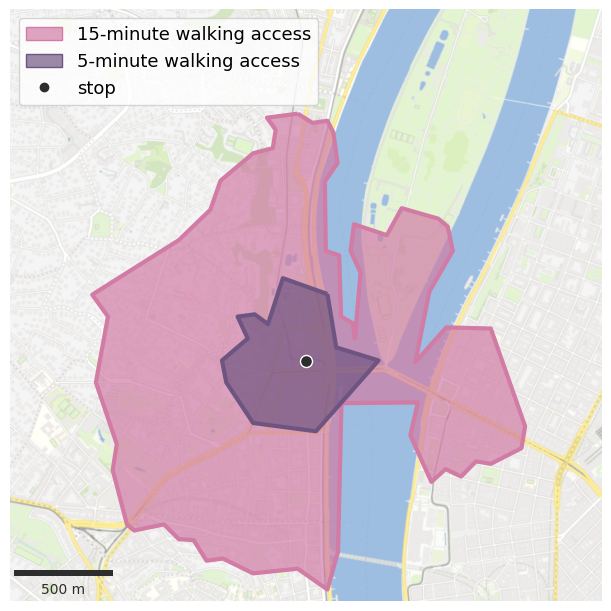

In [75]:
fig, ax = plt.subplots(figsize=(6, 6), layout="constrained")
a15.to_crs(23700).plot(ax=ax, ec=c15, fc=c15+"af", lw=3)
a5.to_crs(23700).plot(ax=ax, ec=c5, fc=c5+"af", lw=3)
stops[stops["stop_id"]==STOP].to_crs(23700).plot(ax=ax, color="#2d2d2d", ec="white", markersize=75)
ax.set_xlim([647800, 650800])
ax.set_ylim([240025, 243025])
ax.axis("off")
ax.margins(0)
cx.add_basemap(
    ax,
    crs=23700,
    source=cx.providers.OpenStreetMap.BZH,
    alpha=0.75,
    zoom=15,
    attribution=False,
)
_ = ax.add_artist(ScaleBar(1, units="m", location="lower left", box_alpha=0, color="#2d2d2d"))
elements = [
    Patch(ec=c15, fc=c15+"af", label="15-minute walking access"),
    Patch(ec=c5, fc=c5+"af", label="5-minute walking access"),
    Line2D([0], [0], color="#2d2d2d", marker="o", linestyle="none", label="stop")
]
_ = ax.legend(handles=elements, ncols=1, loc="upper left", fontsize=13)

for i in ["png", "pdf"]:
    fig.savefig(f"../output/figures/isochrones.{i}", pad_inches=0, metadata=config["metadata"][i], bbox_inches="tight")